In [ ]:
import sys
from glob import glob
import vaex

sys.path.append("../")

base = "../data/parsed/sparse"
patterns = [
    "candump-2020-01-29_115602.log_chunk_*.hdf5",
    "candump-2020-01-30_054738.log_chunk_*.hdf5",
    "candump-2020-01-30_172000.log_chunk_*.hdf5",
    "candump-2020-02-01_064223.log_chunk_*.hdf5",
    "candump-2020-02-01_064222.log_chunk_*.hdf5",
]
chunk_files = []
for p in patterns:
    chunk_files += sorted(glob(f"{base}/{p}"))
bad = []
for chunk in chunk_files:
    comb = chunk.replace("_chunk_", "_combined_chunk_")

    df0 = vaex.open(chunk)
    df1 = vaex.open(comb)

    t0 = df0.minmax("timestamp")
    t1 = df1.minmax("timestamp")

    n0 = len(df0)
    n1 = len(df1)

    ok = (t0[0] == t1[0]) and (t0[1] == t1[1]) and (n1 >= n0)
    if not ok:
        bad.append((chunk, comb, t0, t1, n0, n1))
print("checked:", len(chunk_files), "bad:", len(bad))
for item in bad[:10]:
    print(item)

checked: 77 bad: 0


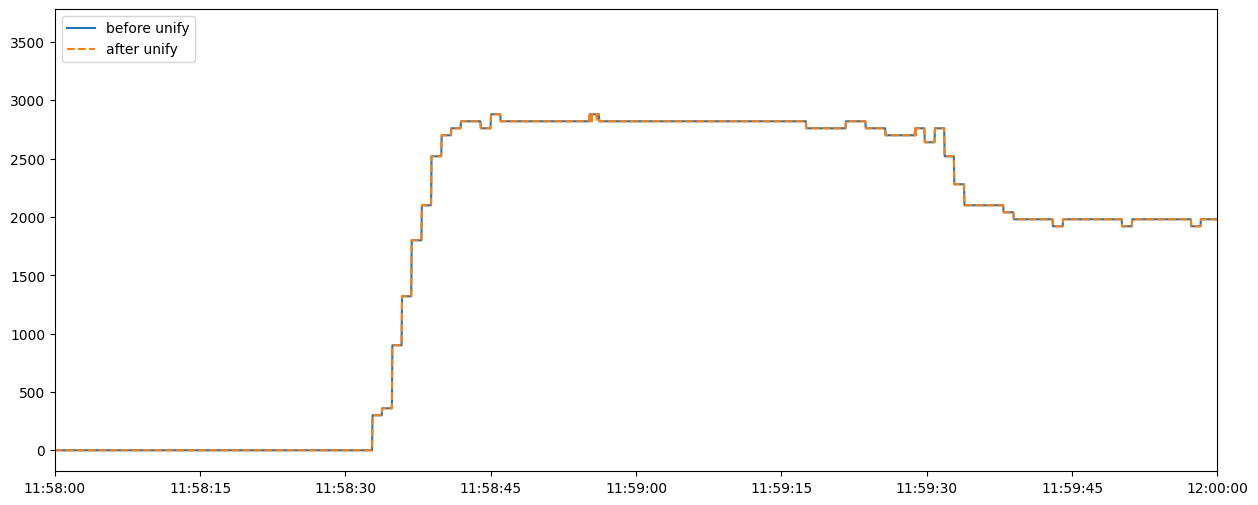

CPU times: user 5.44 s, sys: 10.6 s, total: 16.1 s
Wall time: 31.6 s


In [4]:
%%time

import sys
import pandas as pd
import matplotlib.pyplot as plt
import vaex

sys.path.append('../')

SIGNAL = "MT19__RPM__AVG"
t_start = pd.Timestamp("2020-02-02 11:58:00")
t_end = pd.Timestamp("2020-02-02 12:00:00")

PATH1 = "../data/parsed/sparse/candump-2020-02-*.log_chunk_*.hdf5"
df1 = vaex.open(PATH1).to_pandas_df()[["timestamp", SIGNAL]].dropna()
df1['timestamp'] = pd.to_datetime(df1['timestamp'])
df1 = df1.set_index("timestamp").sort_index()
PATH2 = "../data/parsed/sparse/candump-2020-02-*.log_combined_chunk_*.hdf5"
df2 = vaex.open(PATH2).to_pandas_df()[["timestamp", SIGNAL]].dropna()
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2 = df2.set_index("timestamp").sort_index()

fig = plt.figure(figsize=(15,6))
plt.plot(df1.index, df1[SIGNAL], label="before unify")
plt.plot(df2.index, df2[SIGNAL], '--', label="after unify")
plt.xlim([t_start, t_end])
plt.legend(loc='upper left')
plt.show()